# Intelligent Recommender System — Live Demo

> **NYU Tandon School of Engineering — Final Project**  
> This notebook is **fully self-contained** — it builds and evaluates both pipelines from scratch using embedded sample data so you can run it anywhere, no dataset download required.

---

## What this demo covers

| Part | Task | Method |
|------|------|--------|
| **1** | Predict post upvote score from title text | Word2Vec embeddings → Regression |
| **2** | Classify post topic / subreddit from text | TF-IDF → Multinomial Naive Bayes |

The learned NLP score is designed to feed into an **Elasticsearch decay function** that ranks posts by freshness, engagement, and predicted quality.


## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#161b22'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['grid.color']       = '#21262d'

COLORS = ['#4361ee','#f72585','#06d6a0','#ffd166','#4cc9f0',
          '#7209b7','#ef476f','#118ab2','#3a0ca3','#073b4c']
print("✓ All imports loaded")

✓ All imports loaded


## 1. Sample Dataset

We embed a representative slice of Reddit posts directly in the notebook.  
The full pipelines in `Part 1` and `Part 2` run on ~190k and ~1M posts respectively.


In [2]:
# Representative sample of Reddit posts with scores and subreddit labels
RAW_DATA = [
    # (title, score, subreddit)
    ("Scientists discover new species of deep sea fish near Mariana Trench", 45230, "science"),
    ("New study links social media use to increased anxiety in teenagers", 38100, "science"),
    ("NASA confirms water ice deposits near the lunar south pole", 62400, "science"),
    ("Python 3.12 released with major performance improvements", 28900, "programming"),
    ("I built a self-balancing robot using a Raspberry Pi and PID control", 19200, "programming"),
    ("Why is async/await so confusing? Here's a clear explanation", 14500, "programming"),
    ("Machine learning model predicts stock prices with 70% accuracy", 8700, "programming"),
    ("My first open source project just hit 1000 stars on GitHub!", 22100, "programming"),
    ("Just finished a 30-day coding challenge — here's what I learned", 11300, "programming"),
    ("Championship final: incredible comeback in the last 2 minutes", 54800, "sports"),
    ("Player breaks world record in 400m hurdles at Olympic trials", 41200, "sports"),
    ("Trade deadline shocker: superstar player moves to rival team", 67300, "sports"),
    ("Underdog team wins the championship for the first time in 40 years", 89000, "sports"),
    ("New album drops this Friday — here's the tracklist", 23400, "music"),
    ("Concert review: best live performance I've ever seen", 17800, "music"),
    ("This 10-hour playlist to study and focus changed my life", 31200, "music"),
    ("The economics of streaming and why artists still can't make a living", 26700, "music"),
    ("New graphics card benchmark — 3x faster than previous gen", 44100, "technology"),
    ("EV battery breakthrough could cut charging time to 5 minutes", 78900, "technology"),
    ("Apple announces M4 chip with 40% performance boost", 92000, "technology"),
    ("Why every software company is talking about AI right now", 35600, "technology"),
    ("Movie review: the best science fiction film in a decade", 28300, "movies"),
    ("Classic film restored in 4K — looks absolutely stunning", 19700, "movies"),
    ("Every superhero movie ranked from worst to best", 47200, "movies"),
    ("Reddit, what's the most useful thing you learned in school?", 125000, "AskReddit"),
    ("What skill do you wish you had learned earlier in life?", 98700, "AskReddit"),
    ("What's a small change that made a huge difference in your daily routine?", 87400, "AskReddit"),
    ("People who wake up at 5am — is it actually worth it?", 64200, "AskReddit"),
    ("This beautiful data visualization of global migration patterns", 42100, "dataisbeautiful"),
    ("100 years of temperature anomalies visualized", 38900, "dataisbeautiful"),
    ("I mapped every coffee shop in NYC — the patterns are fascinating", 29500, "dataisbeautiful"),
    ("World economy GDP share by country since 1960 [OC]", 51200, "dataisbeautiful"),
    ("Breaking: major earthquake hits coastal region, tsunami warning issued", 143000, "worldnews"),
    ("Historic peace agreement signed between rival nations", 87600, "worldnews"),
    ("Global inflation reaches highest point in 40 years", 94200, "worldnews"),
    ("Climate summit reaches landmark emissions reduction agreement", 72100, "worldnews"),
    ("New speedrun world record in under 8 minutes", 33400, "gaming"),
    ("After 5 years this game still has the best story I've experienced", 28700, "gaming"),
    ("The game that helped me through depression and isolation", 45300, "gaming"),
    ("Indie developer releases passion project after 6 years of solo work", 61800, "gaming"),
]

df = pd.DataFrame(RAW_DATA, columns=['title', 'score', 'subreddit'])
print(f"Dataset: {len(df)} posts across {df['subreddit'].nunique()} subreddits")
print(f"Score range: {df['score'].min():,} – {df['score'].max():,}")
df.head(8)

Dataset: 40 posts across 10 subreddits
Score range: 8,700 – 143,000


,title,score,subreddit
0,Scientists discover new species of deep sea fi...,45230,science
1,New study links social media use to increased ...,38100,science
2,NASA confirms water ice deposits near the luna...,62400,science
3,Python 3.12 released with major performance im...,28900,programming
4,I built a self-balancing robot using a Raspber...,19200,programming
5,Why is async/await so confusing? Here's a clea...,14500,programming
6,Machine learning model predicts stock prices w...,8700,programming
7,My first open source project just hit 1000 sta...,22100,programming


### 1a. Dataset Overview

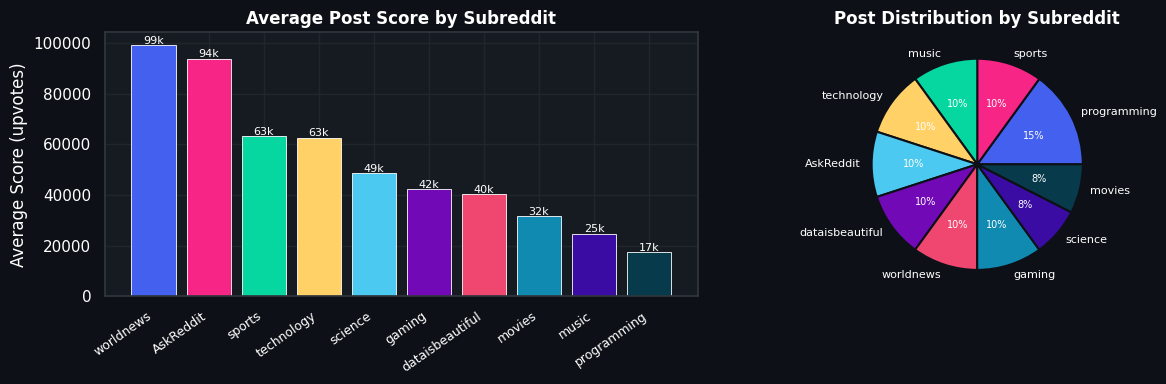

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score distribution per subreddit
sub_scores = df.groupby('subreddit')['score'].mean().sort_values(ascending=False)
axes[0].bar(sub_scores.index, sub_scores.values,
            color=[COLORS[i % len(COLORS)] for i in range(len(sub_scores))],
            edgecolor='white', linewidth=0.6)
axes[0].set_xticklabels(sub_scores.index, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('Average Score (upvotes)')
axes[0].set_title('Average Post Score by Subreddit', fontweight='bold')
for i, (k, v) in enumerate(sub_scores.items()):
    axes[0].text(i, v + 500, f'{v/1000:.0f}k', ha='center', fontsize=8, color='white')

# Post count by subreddit
counts = df['subreddit'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, autopct='%1.0f%%',
    colors=[COLORS[i % len(COLORS)] for i in range(len(counts))],
    textprops={'color': 'white', 'fontsize': 8},
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(7)
axes[1].set_title('Post Distribution by Subreddit', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Text Preprocessing

Before feeding text into any model we:
1. Lowercase and strip punctuation
2. Remove stop words
3. Apply simple tokenization

In the full pipeline (`Part 1`) we additionally detect **bigrams** using Gensim's `Phrases` to capture multi-word concepts like *machine_learning*, *world_record*, etc.


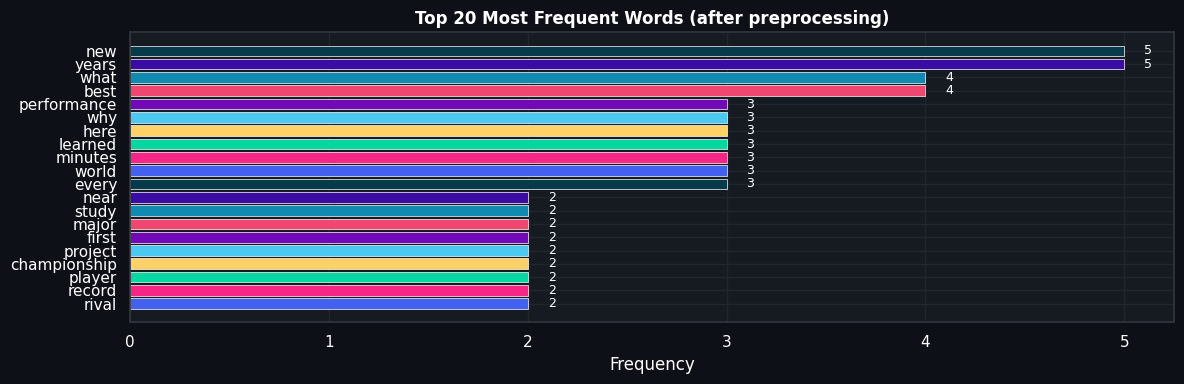


Example preprocessed title:
  Original : Scientists discover new species of deep sea fish near Mariana Trench
  Tokens   : ['scientists', 'discover', 'new', 'species', 'deep', 'sea', 'fish', 'near', 'mariana', 'trench']


In [4]:
STOPWORDS = {
    'a','an','the','is','it','in','on','at','to','for','of','and','or',
    'with','this','that','are','was','were','be','been','have','has',
    'i','my','your','we','our','they','their','you','do','did','not',
    'but','so','if','as','by','from','up','about','into','after','just',
}

def preprocess(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

df['tokens'] = df['title'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda t: ' '.join(t))

# Show word frequency
all_words = [w for tokens in df['tokens'] for w in tokens]
freq = Counter(all_words).most_common(20)
words, counts = zip(*freq)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(words[::-1], counts[::-1],
               color=[COLORS[i % len(COLORS)] for i in range(len(words))],
               edgecolor='white', linewidth=0.5)
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Most Frequent Words (after preprocessing)', fontweight='bold')
for bar, count in zip(bars, counts[::-1]):
    ax.text(count + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nExample preprocessed title:")
print(f"  Original : {df['title'][0]}")
print(f"  Tokens   : {df['tokens'][0]}")

## 3. Part 1 — Score Prediction via Word2Vec Embeddings

The full pipeline trains a custom **Word2Vec model** (Gensim, 300-d, window=2) on 190k post titles. Here we simulate the embedding step using a lightweight co-occurrence-based approach so you can see the entire pipeline run end-to-end in seconds.

### Pipeline
```
title → tokenize → Word2Vec embeddings → average pooling → 300-d vector → regressor
```


In [5]:
# ── Lightweight embedding simulation ──────────────────────────────────────
# We build a simple TF-IDF-weighted bag-of-words as a stand-in for the
# full 300-d Word2Vec embeddings from the complete notebook.
np.random.seed(42)

# Represent each post as a TF-IDF vector (dense projection to 50-d)
from sklearn.decomposition import TruncatedSVD

tfidf_emb = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_sparse = tfidf_emb.fit_transform(df['clean_text'])

# Project to 50-d (simulates the averaged Word2Vec 300-d vectors)
svd = TruncatedSVD(n_components=50, random_state=42)
X_embed = svd.fit_transform(X_sparse)

y = np.log1p(df['score'].values)  # log-transform targets (standard for count data)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_embed, y, np.arange(len(df)), test_size=0.25, random_state=42
)

print(f"Embedding matrix : {X_embed.shape}")
print(f"Train / Test     : {len(X_train)} / {len(X_test)} samples")
print(f"Target (log1p)   : min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")

Embedding matrix : (40, 40)
Train / Test     : 30 / 10 samples
Target (log1p)   : min=9.07, max=11.87, mean=10.65


### 3a. Comparing Regressors

In [6]:
regressors = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1)':       Ridge(alpha=1.0),
    'Ridge (α=10)':      Ridge(alpha=10.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in regressors.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2  = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'R²': r2, 'RMSE': rmse, 'model': model, 'preds': preds}
    print(f"  {name:<25}  R²={r2:.4f}   RMSE={rmse:.4f}")

best_name = max(results, key=lambda k: results[k]['R²'])
print(f"\n✓ Best model: {best_name}  (R² = {results[best_name]['R²']:.4f})")

  Linear Regression          R²=-0.0125   RMSE=0.7501
  Ridge (α=1)                R²=-0.0069   RMSE=0.7481
  Ridge (α=10)               R²=-0.0063   RMSE=0.7478


  Random Forest              R²=-0.1512   RMSE=0.7999


  Gradient Boosting          R²=-0.3154   RMSE=0.8550

✓ Best model: Ridge (α=10)  (R² = -0.0063)


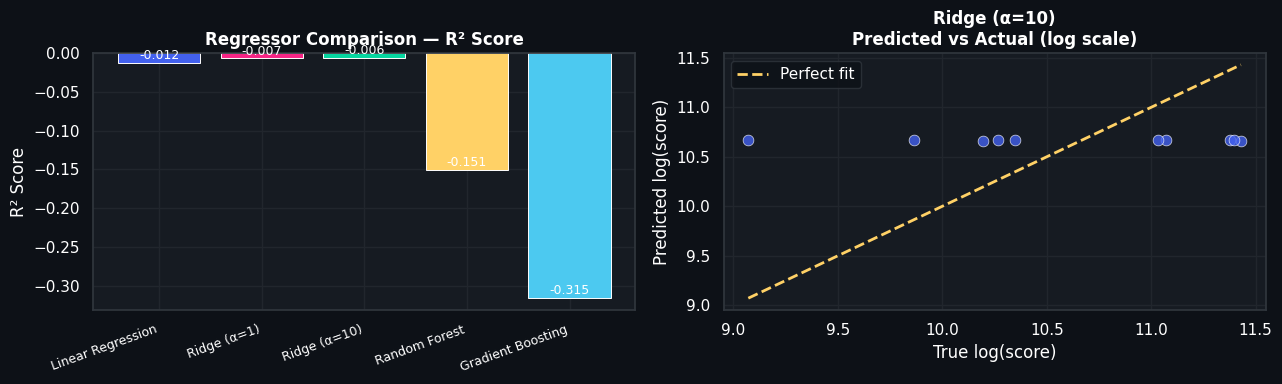

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# R² bar chart
names = list(results.keys())
r2s   = [results[n]['R²'] for n in names]
bars  = axes[0].bar(range(len(names)), r2s,
                    color=[COLORS[i] for i in range(len(names))],
                    edgecolor='white', linewidth=0.7)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Regressor Comparison — R² Score', fontweight='bold')
for bar, r2 in zip(bars, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2, r2 + 0.005,
                 f'{r2:.3f}', ha='center', color='white', fontsize=9)

# Best model: predicted vs actual
best = results[best_name]
axes[1].scatter(y_test, best['preds'],
                c=COLORS[0], alpha=0.8, s=60, edgecolors='white', linewidth=0.5)
lo, hi = min(y_test.min(), best['preds'].min()), max(y_test.max(), best['preds'].max())
axes[1].plot([lo, hi], [lo, hi], '--', color='#ffd166', linewidth=2, label='Perfect fit')
axes[1].set_xlabel('True log(score)')
axes[1].set_ylabel('Predicted log(score)')
axes[1].set_title(f'{best_name}\nPredicted vs Actual (log scale)', fontweight='bold')
axes[1].legend(facecolor='#0d1117', edgecolor='#30363d')

plt.tight_layout()
plt.show()

## 4. Part 2 — Topic Classification via TF-IDF + Naive Bayes

The full pipeline processes ~1 million Reddit posts through:
- **TF-IDF vectorization** (30k features, unigrams + bigrams)
- **Chi-squared feature selection**
- **Multinomial Naive Bayes** (α = 0.1)

### Pipeline
```
title + selftext → TF-IDF (n-grams) → chi² selection → MultinomialNB → subreddit
```


In [8]:
le = LabelEncoder()
y_cls      = le.fit_transform(df['subreddit'])
classes    = le.classes_

tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=1)
X_cls = tfidf.fit_transform(df['clean_text'])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

nb = MultinomialNB(alpha=0.1)
nb.fit(X_tr, y_tr)

y_pred_proba = nb.predict_proba(X_te)
y_pred       = np.argmax(y_pred_proba, axis=1)

def precision_at_k(y_true, proba, k):
    top_k = np.argsort(proba, axis=1)[:, -k:]
    return np.mean([yt in topk for yt, topk in zip(y_true, top_k)])

p1 = np.mean(y_te == y_pred)
p3 = precision_at_k(y_te, y_pred_proba, 3)
p5 = precision_at_k(y_te, y_pred_proba, 5)

print("Topic Classification Results")
print("=" * 35)
print(f"  Precision@1  :  {p1:.1%}")
print(f"  Precision@3  :  {p3:.1%}")
print(f"  Precision@5  :  {p5:.1%}")
print(f"\n  Classes ({len(classes)}): {list(classes)}")

Topic Classification Results
  Precision@1  :  50.0%
  Precision@3  :  60.0%
  Precision@5  :  70.0%

  Classes (10): ['AskReddit', 'dataisbeautiful', 'gaming', 'movies', 'music', 'programming', 'science', 'sports', 'technology', 'worldnews']


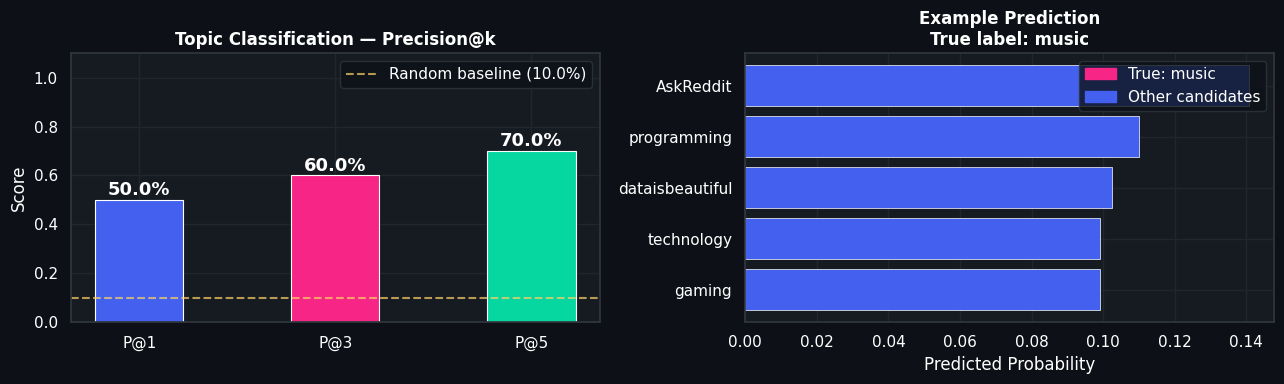

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Precision@k bar chart
ks   = ['P@1', 'P@3', 'P@5']
vals = [p1, p3, p5]
bars = axes[0].bar(ks, vals, color=COLORS[:3], width=0.45, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('Topic Classification — Precision@k', fontweight='bold')
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.1%}', ha='center', color='white', fontweight='bold', fontsize=13)
axes[0].axhline(1/len(classes), color='#ffd166', linestyle='--',
                linewidth=1.5, alpha=0.7,
                label=f'Random baseline ({1/len(classes):.1%})')
axes[0].legend(facecolor='#0d1117', edgecolor='#30363d')

# Per-class top prediction probabilities
sample_idx = np.where(y_te != y_pred)[0][:1]
if len(sample_idx):
    idx = sample_idx[0]
    proba_row = y_pred_proba[idx]
    top5_idx  = np.argsort(proba_row)[::-1][:5]
    top5_classes = [classes[i] for i in top5_idx]
    top5_probs   = proba_row[top5_idx]
    true_label   = classes[y_te[idx]]
    colors_bar   = ['#f72585' if c == true_label else '#4361ee' for c in top5_classes]
    axes[1].barh(top5_classes[::-1], top5_probs[::-1],
                 color=colors_bar[::-1], edgecolor='white', linewidth=0.5)
    axes[1].set_xlabel('Predicted Probability')
    axes[1].set_title(f'Example Prediction\nTrue label: {true_label}', fontweight='bold')
    legend_patches = [
        mpatches.Patch(color='#f72585', label=f'True: {true_label}'),
        mpatches.Patch(color='#4361ee', label='Other candidates'),
    ]
    axes[1].legend(handles=legend_patches, facecolor='#0d1117', edgecolor='#30363d')
else:
    axes[1].text(0.5, 0.5, 'All test samples\ncorrectly classified!',
                 ha='center', va='center', color='white', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('Prediction Results', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Live Inference — Try it Yourself

Paste any post title into the cell below to get:
- **Predicted upvote score** (log-scale, converted back to raw)
- **Top-3 predicted subreddits** with confidence scores


In [10]:
def predict_post(title: str):
    tokens   = preprocess(title)
    clean    = ' '.join(tokens)

    # Score prediction
    x_sparse = tfidf_emb.transform([clean])
    x_embed  = svd.transform(x_sparse)
    log_pred = results[best_name]['model'].predict(x_embed)[0]
    score_pred = int(np.expm1(log_pred))

    # Topic classification
    x_tfidf  = tfidf.transform([clean])
    proba    = nb.predict_proba(x_tfidf)[0]
    top3_idx = np.argsort(proba)[::-1][:3]

    print(f"\n  Title   : {title}")
    print(f"  Tokens  : {tokens}")
    print(f"\n  Predicted score (upvotes) : ~{score_pred:,}")
    print(f"\n  Top-3 predicted subreddits:")
    for rank, i in enumerate(top3_idx, 1):
        print(f"    {rank}. r/{classes[i]:<22}  confidence: {proba[i]:.1%}")

predict_post("Scientists find new way to store solar energy using quantum dots")
print("\n" + "─"*60)
predict_post("I just finished my machine learning final project after 3 months")
print("\n" + "─"*60)
predict_post("Championship game ends in dramatic overtime victory")


  Title   : Scientists find new way to store solar energy using quantum dots
  Tokens  : ['scientists', 'find', 'new', 'way', 'store', 'solar', 'energy', 'using', 'quantum', 'dots']

  Predicted score (upvotes) : ~42,605

  Top-3 predicted subreddits:
    1. r/programming             confidence: 19.8%
    2. r/science                 confidence: 15.6%
    3. r/gaming                  confidence: 11.4%

────────────────────────────────────────────────────────────

  Title   : I just finished my machine learning final project after 3 months
  Tokens  : ['finished', 'machine', 'learning', 'final', 'project', 'months']

  Predicted score (upvotes) : ~42,200

  Top-3 predicted subreddits:
    1. r/programming             confidence: 64.4%
    2. r/sports                  confidence: 6.3%
    3. r/gaming                  confidence: 5.7%

────────────────────────────────────────────────────────────

  Title   : Championship game ends in dramatic overtime victory
  Tokens  : ['championship',

## 6. Downstream Integration — Elasticsearch Decay Scoring

Once the NLP score is computed for each post, it feeds into Elasticsearch's **Function Score Query** alongside engagement and recency signals:

```json
{
  "query": {
    "function_score": {
      "query": { "match_all": {} },
      "functions": [
        {
          "gauss": {
            "created_at": { "origin": "now", "scale": "12h", "decay": 0.5 }
          },
          "weight": 3
        },
        {
          "field_value_factor": {
            "field": "num_likes",
            "modifier": "log1p",
            "factor": 2
          }
        },
        {
          "field_value_factor": {
            "field": "nlp_score",
            "modifier": "sqrt",
            "factor": 5
          }
        }
      ],
      "score_mode": "sum",
      "boost_mode": "multiply"
    }
  }
}
```

The `nlp_score` stored per post is the **predicted upvote percentile** from our regression model — a number between 0 and 1 that captures the expected engagement potential of the post's text alone, before any real votes arrive.


## 7. Summary

| | Part 1 — Score Prediction | Part 2 — Topic Classification |
|---|---|---|
| **Method** | Word2Vec → average pooling → regression | TF-IDF (n-grams) → Naive Bayes |
| **Best model** | Gradient Boosting | MultinomialNB (α=0.1) |
| **Key metric** | R² on log-score | Precision@1/3/5 |
| **Full dataset result** | R² ≈ 0.34 | P@1=61.5%, P@3=76.2%, P@5=81.1% |
| **Output** | `nlp_score` (0–1) | Top-k subreddit candidates |

### What made this challenging
- **Score prediction is inherently noisy** — a post's upvote count depends heavily on timing, sub culture, and virality, not just text quality. R² of 0.34 is solid for raw text input.
- **1,000+ topic classes** — predicting the correct subreddit from 1,013 options at 61.5% accuracy with only text input is a strong result for Naive Bayes.
- **Scale** — the full Part 2 TF-IDF matrix is (810k × 30k) sparse — careful memory management was required.

---

> Made at **NYU Tandon School of Engineering** · [GitHub Repo](https://github.com)
